In [11]:
import matplotlib.pyplot as plt

class Graph:
    def __init__(self, size):
        self.adj_matrix = [[0] * size for _ in range(size)]
        self.size = size
        self.vertex_data = [''] * size

    def add_edge(self, u, v, weight):
        if 0 <= u < self.size and 0 <= v < self.size:
            self.adj_matrix[u][v] = weight
            self.adj_matrix[v][u] = weight  # For undirected graph

    def add_vertex_data(self, vertex, data):
        if 0 <= vertex < self.size:
            self.vertex_data[vertex] = data

    def dijkstra(self, start_vertex_data):
        start_vertex = self.vertex_data.index(start_vertex_data)
        distances = [float('inf')] * self.size
        distances[start_vertex] = 0
        visited = [False] * self.size
        previous = [None] * self.size  # To track the shortest path

        for _ in range(self.size):
            min_distance = float('inf')
            u = None
            for i in range(self.size):
                if not visited[i] and distances[i] < min_distance:
                    min_distance = distances[i]
                    u = i

            if u is None:
                break

            visited[u] = True

            for v in range(self.size):
                if self.adj_matrix[u][v] != 0 and not visited[v]:
                    alt = distances[u] + self.adj_matrix[u][v]
                    if alt < distances[v]:
                        distances[v] = alt
                        previous[v] = u  # Track the shortest path

        # Construct the shortest path as a list of edges
        shortest_paths = []
        for i in range(self.size):
            if previous[i] is not None:
                shortest_paths.append((previous[i], i))

        return distances, shortest_paths





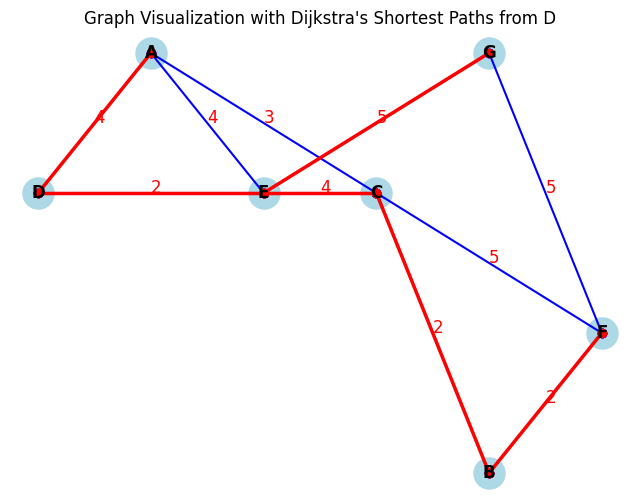

In [12]:
# Create graph and define its vertices and edges
g = Graph(7)
g.add_vertex_data(0, 'A')
g.add_vertex_data(1, 'B')
g.add_vertex_data(2, 'C')
g.add_vertex_data(3, 'D')
g.add_vertex_data(4, 'E')
g.add_vertex_data(5, 'F')
g.add_vertex_data(6, 'G')

g.add_edge(3, 0, 4)  # D - A, weight 4
g.add_edge(3, 4, 2)  # D - E, weight 2
g.add_edge(0, 2, 3)  # A - C, weight 3
g.add_edge(0, 4, 4)  # A - E, weight 4
g.add_edge(4, 2, 4)  # E - C, weight 4
g.add_edge(4, 6, 5)  # E - G, weight 5
g.add_edge(2, 5, 5)  # C - F, weight 5
g.add_edge(2, 1, 2)  # C - B, weight 2
g.add_edge(1, 5, 2)  # B - F, weight 2
g.add_edge(6, 5, 5)  # G - F, weight 5

# Run Dijkstra from vertex 'D'
distances, shortest_paths = g.dijkstra('D')

# Coordinates for nodes for manual positioning
positions = {
    'A': (1, 3),
    'B': (4, 0),
    'C': (3, 2),
    'D': (0, 2),
    'E': (2, 2),
    'F': (5, 1),
    'G': (4, 3),
}

# Map shortest path edges from indices to vertex names
edge_map = {i: node for i, node in enumerate(g.vertex_data)}
highlight_edges = [(edge_map[u], edge_map[v]) for u, v in shortest_paths]

# Plot setup
plt.figure(figsize=(8, 6))

# All edges with weights
edges = [
    ('D', 'A', 4), ('D', 'E', 2), ('A', 'C', 3), ('A', 'E', 4), 
    ('E', 'C', 4), ('E', 'G', 5), ('C', 'F', 5), ('C', 'B', 2), 
    ('B', 'F', 2), ('G', 'F', 5)
]

# Draw all edges in light blue
for edge in edges:
    node1, node2, weight = edge
    x_values = [positions[node1][0], positions[node2][0]]
    y_values = [positions[node1][1], positions[node2][1]]
    plt.plot(x_values, y_values, 'bo-', linewidth=1.5)
    plt.text(sum(x_values) / 2, sum(y_values) / 2, str(weight), fontsize=12, color='red')

# Highlight shortest path edges in red
for edge in highlight_edges:
    node1, node2 = edge
    x_values = [positions[node1][0], positions[node2][0]]
    y_values = [positions[node1][1], positions[node2][1]]
    plt.plot(x_values, y_values, 'ro-', linewidth=2.5)

# Draw nodes
for node, (x, y) in positions.items():
    plt.scatter(x, y, s=500, color='lightblue')
    plt.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

# Display graph
plt.title("Graph Visualization with Dijkstra's Shortest Paths from D")
plt.axis('off')  # Hide axis
plt.show()